# 2. Analyzing Building Stock Patterns

## 2.1 Preparing the Analytical Dataset

In {doc}`1. The Data Up Close: Saarland <203a_introduction>`, we explored raw building footprints for Saarland. Now we scale up to **all of Germany** using a pre-aggregated dataset.

The dataset contains building statistics for **10,925 municipalities** across Germany, produced by the spatial join and aggregation pipeline documented in {doc}`3. Building the Analytical Foundation <203c_pipeline_documentation>`.

This dataset is provided with this book — no need to download the full 5 GB footprint data.

### Setup

First, we load the required libraries and define paths.

In [15]:
# ============================================================
# Setup and paths
# ============================================================
from pathlib import Path
import pandas as pd
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.colors import to_rgba
import matplotlib.image as mpimg

# Define root directory (adjust if needed)
ROOT = Path.cwd().parent

# Path to aggregated building statistics (provided, from Chapter 3)
AGG_PATH = ROOT / "data" / "processed" / "3d_building_metrics_germany_2024_stats_by_municipality.csv"

# Path to BBSR classifications (RegioStaR)
BBSR_PATH = ROOT / "data" / "raw" / "BBSR-Raumliederungen" / "bbsr-raumgliederungen-referenzen-2024_gemeinden.csv"

# Path to VWG geometries (GeoPackage from BKG)
VG25_GPKG_PATH = ROOT / "data" / "raw" / "VG25" / "Daten" / "DE_VG25.gpkg"

# Path to logo image
LOGO_IOER_PATH = ROOT / "resources" / "IOER_Logo_EN_screen_RGB_mono-schwarz_h400.png"

print(f"Aggregated building statistics exist: {AGG_PATH.exists()}")
print(f"BBSR RegioStaR classifications exist: {BBSR_PATH.exists()}")
print(f"VG25 administrative boundaries (GeoPackage) exist: {VG25_GPKG_PATH.exists()}")

Aggregated building statistics exist: True
BBSR RegioStaR classifications exist: True
VG25 administrative boundaries (GeoPackage) exist: True


### Load Aggregated Building Statistics

We load the pre-aggregated municipality-level data produced in {doc}`# 3. Building the Analytical Foundation <203c_pipeline_documentation>`. This contains one row per municipality (Gemeinde) with building counts, volumes, roof areas, and footprint areas.

In [16]:
# ============================================================
# Load aggregated building statistics
# ============================================================
agg_df = pd.read_csv(
    AGG_PATH,
    dtype={
        'ags': 'object',
        'gemeinde_name': 'object',
        'n_buildings': 'int',
        'total_volume_m3': 'float',
        'avg_volume_m3': 'float',
        'total_roof_area_m2': 'float',
        'avg_roof_area_m2': 'float',
        'total_footprint_m2': 'float',
        'avg_footprint_m2': 'float'
    }
)

print(f"Loaded {len(agg_df):,} municipalities")
print(f"Columns: {list(agg_df.columns)}")
print()
agg_df.head()

Loaded 10,925 municipalities
Columns: ['ags', 'gemeinde_name', 'n_buildings', 'total_volume_m3', 'avg_volume_m3', 'total_roof_area_m2', 'avg_roof_area_m2', 'total_footprint_m2', 'avg_footprint_m2']



,ags,gemeinde_name,n_buildings,total_volume_m3,avg_volume_m3,total_roof_area_m2,avg_roof_area_m2,total_footprint_m2,avg_footprint_m2
0,01001000,Flensburg,32637,4.317281e+07,1322.8,5384886.04,165.0,4864835.95,149.1
1,01002000,Kiel,61244,9.675341e+07,1579.8,10825713.87,176.8,9727144.18,158.8
2,01003000,Lübeck,107468,9.472069e+07,881.4,13346359.33,124.2,11786148.65,109.7
3,01004000,Neumünster,52736,4.111898e+07,779.7,6420944.31,121.8,5815793.85,110.3
4,01051001,Albersdorf,3151,2.086660e+06,662.2,406480.31,129.0,366552.77,116.3


### Load BBSR Classifications (RegioStaR)

Next, we load the RegioStaR spatial typology from BBSR. This classifies municipalities along the urban-rural continuum.

The full BBSR reference table contains many spatial typologies (e.g., Degree of Urbanisation, Stadt- und Gemeindetyp, etc.). Here, we select only the RegioStaR columns needed for this analysis.


**Data source:** BBSR Raumgliederungen (Referenztabellen), © BBSR, Datenlizenz Deutschland – Namensnennung – Version 2.0, reference date 31.12.2024.  
**Download:** [raumgliederungen-referenzen-2024.xlsx](https://www.bbsr.bund.de/BBSR/DE/forschung/raumbeobachtung/Raumabgrenzungen/downloads/raumgliederungen-referenzen-2024.xlsx?__blob=publicationFile&v=6)  
**Documentation:** [Raumabgrenzungen Übersicht](https://www.bbsr.bund.de/BBSR/DE/forschung/raumbeobachtung/Raumabgrenzungen/raumabgrenzungen-uebersicht)  
**RegioStaR reference:** [RegioStaR Raumtypologie (English)](https://www.bmv.de/SharedDocs/DE/Anlage/G/regiostar-raumtypologie-englisch.pdf?__blob=publicationFile)  
**Quellenangabe:** Bundesinstitut für Bau-, Stadt- und Raumforschung: Laufende Raumbeobachtung des BBSR

In [17]:
# ============================================================
# Load BBSR classifications (RegioStaR only)
# ============================================================
# The full BBSR table contains many spatial typologies.
# We select only the columns needed for this analysis.
df_bbsr = pd.read_csv(
    BBSR_PATH,
    sep=';',
    encoding='iso-8859-1',
    usecols=[
        'GEM2024', 'GEM2024_RS', 'GEM_NAME', 'bev24',
        'VWG2024', 'VWG_NAME', 'RSS2024', 'RSS_NAME'
    ],
    dtype={
        'GEM2024': 'object',
        'GEM2024_RS': 'object',
        'GEM_NAME': 'object',
        'bev24': 'int',
        'VWG2024': 'object',
        'VWG_NAME': 'object',
        'RSS2024': 'object',
        'RSS_NAME': 'object'
    }
)

# Rename columns
df_bbsr = df_bbsr.rename(columns={
    'GEM2024': 'ags',
    'GEM2024_RS': 'ars',
    'GEM_NAME': 'gemeinde_name',
    'bev24': 'population',
    'VWG2024': 'ars_vwg',
    'VWG_NAME': 'vwg_name',
    'RSS2024': 'regiostar17_code',
    'RSS_NAME': 'regiostar17_name'
})

print(f"Loaded {len(df_bbsr):,} municipalities")
print(f"Columns: {list(df_bbsr.columns)}")
df_bbsr.head()

Loaded 10,956 municipalities
Columns: ['ags', 'ars', 'gemeinde_name', 'population', 'ars_vwg', 'vwg_name', 'regiostar17_code', 'regiostar17_name']


,ags,ars,gemeinde_name,population,ars_vwg,vwg_name,regiostar17_code,regiostar17_name
0,01001000,010010000000,"Flensburg, Stadt",96326,010010000,"Flensburg, Stadt",221,Periphere lndliche Region - Zentrale Stadt
1,01002000,010020000000,"Kiel, Landeshauptstadt",252668,010020000,"Kiel, Landeshauptstadt",121,Regiopolitane Stadtregion - Regiopole
2,01003000,010030000000,"Lbeck, Hansestadt",216889,010030000,"Lbeck, Hansestadt",121,Regiopolitane Stadtregion - Regiopole
3,01004000,010040000000,"Neumnster, Stadt",79809,010040000,"Neumnster, Stadt",211,Stadtregionsnahe lndliche Region - Zentrale S...
4,01051001,010515175001,Albersdorf,3742,010515175,Mitteldithmarschen,225,"Periphere lndliche Region - Kleinstdtischer,..."


### Derive RegioStaR4 from RegioStaR17

The BBSR provides RegioStaR at different levels of aggregation. In the previous step, we imported the **RegioStaR17** classification (3-digit codes, e.g., `111`, `221`). For this analysis, we want to work with the broader **RegioStaR4** level (2-digit codes, e.g., `11`, `22`), which aggregates the 17 detailed types into 4 macro-level regional categories.

RegioStaR4 is derived from RegioStaR17 by **removing the last digit** of the 3-digit code:

| RegioStaR4 Code | RegioStaR4 Name | RegioStaR17 Codes (examples) |
|-----------------|-----------------|------------------------------|
| `11` | Metropolitan urban region | `111`, `112`, `113`, ... |
| `12` | Regiopolitan urban region | `121`, `122`, `123`, ... |
| `21` | Rural region close to an urban region | `211`, `212`, `213`, ... |
| `22` | Peripheral rural region | `221`, `222`, `223`, ... |

This hierarchical relationship allows us to work with the more aggregated RegioStaR4 level while retaining the option to drill down to RegioStaR17 if needed.

In [18]:
# ============================================================
# Derive RegioStaR4 from RegioStaR17
# ============================================================
df_bbsr['regiostar4_code'] = df_bbsr['regiostar17_code'].str[:-1]

regiostar4_labels = {
    '11': 'Metropolitan urban region',
    '12': 'Regiopolitan urban region',
    '21': 'Rural region close to an urban region',
    '22': 'Peripheral rural region'
}
df_bbsr['regiostar4_name'] = df_bbsr['regiostar4_code'].map(regiostar4_labels)

# Print number of municipalities per RegioStaR4 class
print("Number of municipalities per RegioStaR4 class:")
print(df_bbsr['regiostar4_code'].value_counts().sort_index())

Number of municipalities per RegioStaR4 class:
regiostar4_code
11    1468
12    1905
21    3343
22    4240
Name: count, dtype: int64


### Join Building Stats with RegioStaR

We now join the two datasets:

- **`agg_df`** — aggregated building statistics per municipality (from Chapter 3, one row per `ags`)
- **`df_bbsr`** — BBSR reference table with RegioStaR classifications (one row per `ags`)

The join is performed on the municipality code (`ags`) using an **inner join**, so only municipalities present in both datasets are retained.

A small number of municipalities (3) from the building statistics have no match in the BBSR table — these are located in the Deutsch-Luxemburgisches Hoheitsgebiet and are excluded from the analysis.

In [19]:
# ============================================================
# Join building stats with RegioStaR
# ============================================================
bbsr_join = df_bbsr[[
    'ags', 'ars', 'gemeinde_name', 'population',
    'ars_vwg', 'vwg_name',
    'regiostar4_code', 'regiostar4_name'
]].copy()

agg_merged = agg_df.merge(bbsr_join, on='ags', how='inner')

print(f"Aggregated building statistics (municipalities): {len(agg_df):,}")
print(f"BBSR RegioStaR classifications (municipalities): {len(bbsr_join):,}")
print(f"Merged dataset (inner join):                     {len(agg_merged):,}")
print(f"Excluded (no BBSR match):                        {len(agg_df) - len(agg_merged)}")

Aggregated building statistics (municipalities): 10,925
BBSR RegioStaR classifications (municipalities): 10,956
Merged dataset (inner join):                     10,922
Excluded (no BBSR match):                        3


### Aggregate to VWG Level

For nationwide analysis, we aggregate the municipality-level data to **municipal associations (VWGs)**. Individual municipalities in Germany are extremely heterogeneous — ranging from tiny villages with fewer than 10 inhabitants to the metropolis of Berlin. VWGs offer a more **balanced and uniform spatial scale** for comparative analysis.

Since RegioStaR codes are consistent within VWGs, the classification remains unambiguous after aggregation. This gives us **4,559 analytical units** — more comparable than individual municipalities.

In [20]:
# ============================================================
# Aggregate to VWG level
# ============================================================
vwg_agg = agg_merged.groupby('ars_vwg').agg(
    n_municipalities=('ags', 'count'),
    n_buildings=('n_buildings', 'sum'),
    total_volume_m3=('total_volume_m3', 'sum'),
    total_roof_area_m2=('total_roof_area_m2', 'sum'),
    total_footprint_m2=('total_footprint_m2', 'sum'),
    population=('population', 'sum'),
    vwg_name=('vwg_name', 'first'),
    regiostar4_code=('regiostar4_code', 'first'),
    regiostar4_name=('regiostar4_name', 'first')
).reset_index()

print(f"Aggregated to {len(vwg_agg):,} VWGs")
print(f"Total buildings: {vwg_agg['n_buildings'].sum():,}")
print(f"Total population: {vwg_agg['population'].sum():,}")
print()

Aggregated to 4,559 VWGs
Total buildings: 52,130,833
Total population: 83,577,140



### Distribution by RegioStaR4

Let's examine how the **4,559 VWGs**, their **buildings**, and their **population** are distributed across the four RegioStaR4 classes. This gives us a first overview of how the built environment and population are spread along the urban-rural continuum.

In [21]:
# ============================================================
# Distribution by RegioStaR4
# ============================================================
total_vwgs = len(vwg_agg)
total_buildings = vwg_agg['n_buildings'].sum()
total_population = vwg_agg['population'].sum()

dist = vwg_agg.groupby(['regiostar4_code', 'regiostar4_name']).agg(
    n_vwgs=('ars_vwg', 'count'),
    n_buildings=('n_buildings', 'sum'),
    population=('population', 'sum')
).reset_index()

dist['vwg_share'] = dist['n_vwgs'] / total_vwgs * 100
dist['building_share'] = dist['n_buildings'] / total_buildings * 100
dist['population_share'] = dist['population'] / total_population * 100

print(f"{'Class':<10} {'VWGs':>6} {'%VWGs':>7} {'Buildings':>12} {'%Bld':>7} {'Population':>12} {'%Pop':>7}")
print("-" * 65)
for _, row in dist.iterrows():
    print(f"{row['regiostar4_code']:<10} {row['n_vwgs']:>6,} {row['vwg_share']:>6.1f}% "
          f"{row['n_buildings']:>12,} {row['building_share']:>6.1f}% "
          f"{row['population']:>12,} {row['population_share']:>6.1f}%")

Class        VWGs   %VWGs    Buildings    %Bld   Population    %Pop
-----------------------------------------------------------------
11            935   20.5%   16,374,371   31.4%   36,855,347   44.1%
12            768   16.8%   10,070,421   19.3%   16,611,595   19.9%
21          1,198   26.3%   12,545,473   24.1%   15,781,309   18.9%
22          1,658   36.4%   13,140,568   25.2%   14,328,889   17.1%


> **Key Insight:** Metropolitan urban regions (11) have 44% of the population but only 31% of buildings. Peripheral rural regions (22) show the opposite: 17% of population but 25% of buildings. This already indicates **structural differences in building stock composition** across the RegioStaR classes, motivating the concentration analysis that follows.

### Save the Analytical Dataset

We save this dataset for use in the next sections.

In [22]:
# ============================================================
# Save the analytical dataset
# ============================================================
OUTPUT_DIR = ROOT / "data" / "processed"
vwg_agg.to_csv(OUTPUT_DIR / "3d_building_metrics_germany_2024_stats_by_vwg_and_regiostar4.csv", index=False)
vwg_agg.to_parquet(OUTPUT_DIR / "3d_building_metrics_germany_2024_stats_by_vwg_and_regiostar4.parquet", index=False)

print(f"Saved to {OUTPUT_DIR.relative_to(ROOT)}")

Saved to data\processed


## 2.2 Lorenz Curves and Gini Coefficients

Now we analyze how building volume is distributed across VWGs within each RegioStaR4 class.

**Motivation:** Understanding the **concentration** of building volume helps identify where resources (e.g., material stocks, renovation potential) are concentrated — and whether this concentration differs between urban and rural regions.

**Lorenz curve:** Shows cumulative share of building volume (y-axis) against cumulative share of VWGs (x-axis), sorted by volume.

**Gini coefficient:** A number between 0 and 1:
- `0` = perfect equality (all VWGs have the same volume)
- `1` = perfect inequality (one VWG has everything)

### Lorenz Curve Function

We define a function to compute Lorenz curves and Gini coefficients.

In [23]:
# ============================================================
# Lorenz curve function
# ============================================================
def lorenz_curve(values):
    """
    Compute the Lorenz curve and Gini coefficient.
    
    Parameters:
        values: array-like of positive numbers
    
    Returns:
        cum_share_n: cumulative share of entities (x-axis)
        cum_share_value: cumulative share of values (y-axis)
        gini: Gini coefficient (0 = equal, 1 = concentrated)
    """
    # Sort values ascending
    values = np.sort(np.asarray(values, dtype=float))
    values = values[values >= 0]
    n = len(values)
    
    # Handle edge case
    if n == 0 or values.sum() == 0:
        return np.array([0, 1]), np.array([0, 1]), np.nan
    
    # Compute cumulative shares
    cum_values = np.cumsum(values)
    cum_share_value = np.insert(cum_values / cum_values[-1], 0, 0)
    cum_share_n = np.insert(np.arange(1, n + 1) / n, 0, 0)
    
    # Gini coefficient
    gini = 1 - 2 * np.trapezoid(cum_share_value, cum_share_n)
    
    return cum_share_n, cum_share_value, gini

### Plot Lorenz Curves

We plot the Lorenz curves for each RegioStaR4 class. The closer a curve is to the diagonal, the more equal the distribution.

**How to read this chart:**

- **X-axis:** Cumulative share of VWGs — the percentage of VWGs (sorted by building volume, smallest to largest) up to a given point. For example, 0.4 means the 40% of VWGs with the smallest building volumes.
- **Y-axis:** Cumulative share of building volume — the percentage of total building volume held by those VWGs. For example, 0.2 means those same 40% of VWGs hold only 20% of the total building volume.
- **Diagonal line:** Perfect equality (every VWG has the same volume).

**What to look for:**

- A curve that bows **further below the diagonal** indicates **higher concentration** — a small number of VWGs hold a large share of building volume.
- A curve that stays **close to the diagonal** indicates a **more equal distribution** — building volume is spread more evenly across VWGs.

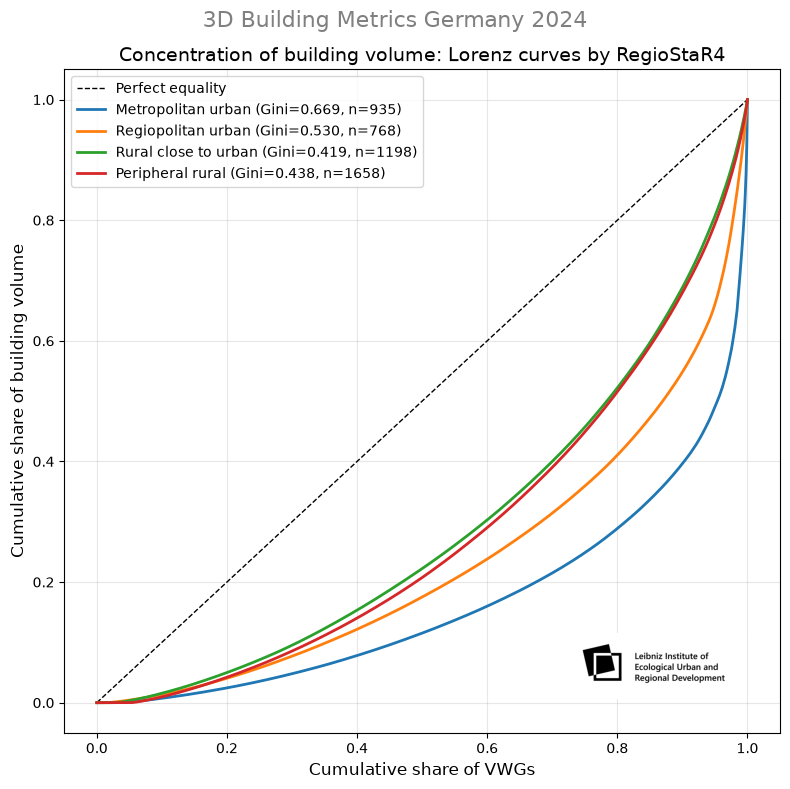

In [24]:
# ============================================================
# Plot Lorenz curves by RegioStaR4
# ============================================================
regiostar4_labels_short = {
    '11': 'Metropolitan urban',
    '12': 'Regiopolitan urban',
    '21': 'Rural close to urban',
    '22': 'Peripheral rural'
}

# load the local LOGO-PNG
logo_img = mpimg.imread(LOGO_IOER_PATH)

fig, ax = plt.subplots(figsize=(8, 8))

# Perfect equality line
ax.plot([0, 1], [0, 1], 'k--', label='Perfect equality', linewidth=1)

# Plot each class
for code in ['11', '12', '21', '22']:
    group = vwg_agg[vwg_agg['regiostar4_code'] == code]
    x, y, gini = lorenz_curve(group['total_volume_m3'])
    label = f"{regiostar4_labels_short[code]} (Gini={gini:.3f}, n={len(group)})"
    ax.plot(x, y, label=label, linewidth=2)

ax.set_xlabel('Cumulative share of VWGs', fontsize=12)
ax.set_ylabel('Cumulative share of building volume', fontsize=12)
fig.suptitle('3D Building Metrics Germany 2024', fontsize=16, y=0.98, color='grey')
ax.set_title('Concentration of building volume: Lorenz curves by RegioStaR4', fontsize=14)
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
logo_ax = fig.add_axes([0.72, 0.05, 0.22, 0.22])
logo_ax.imshow(logo_img)
logo_ax.axis('off')
plt.show()

### What the Curves Show

- **Metropolitan urban** — Curve bows furthest from the diagonal → highest concentration
- **Regiopolitan urban** — Moderate bow → noticeable concentration
- **Rural close to urban** — Closest to diagonal → lowest concentration
- **Peripheral rural** — Similar to rural close to urban → moderate concentration

All classes show moderate to high concentration — none are close to perfect equality.

## 2.3 Concentration Metrics

To quantify these patterns beyond the Gini coefficient (already shown in the plot), we compute:

- **Top 10% share** — percentage of total building volume held by the largest 10% of VWGs in each class
- **Top 20% share** — percentage of total building volume held by the largest 20% of VWGs in each class

These metrics show how much building volume is controlled by the largest VWGs — useful for identifying dominant centers.

In [25]:
# ============================================================
# Concentration metrics by RegioStaR4
# ============================================================
print(f"{'Class':<25} {'VWGs':>6} {'Top10% VWGs':>12} {'Top20% VWGs':>12}")
print("-" * 60)

for code in ['11', '12', '21', '22']:
    group = vwg_agg[vwg_agg['regiostar4_code'] == code]
    
    # Sort volumes descending
    sorted_vals = np.sort(group['total_volume_m3'].values)[::-1]
    total_vol = sorted_vals.sum()
    
    # Top 10% share
    n_top10 = max(1, int(len(group) * 0.1))
    top10_share = sorted_vals[:n_top10].sum() / total_vol * 100
    
    # Top 20% share
    n_top20 = max(1, int(len(group) * 0.2))
    top20_share = sorted_vals[:n_top20].sum() / total_vol * 100
    
    print(f"{regiostar4_labels_short[code]:<25} {len(group):>6,} {top10_share:>11.1f}% {top20_share:>11.1f}%")

Class                       VWGs  Top10% VWGs  Top20% VWGs
------------------------------------------------------------
Metropolitan urban           935        60.3%        71.1%
Regiopolitan urban           768        45.0%        58.9%
Rural close to urban       1,198        31.0%        47.7%
Peripheral rural           1,658        31.9%        48.4%


> **Key Insight:** Building volume is highly concentrated in all RegioStaR4 classes — but the degree of concentration varies. In metropolitan urban regions, the top 10% of VWGs hold 60% of building volume, indicating strong dominance by a few large centers. Even in rural regions, the top 10% of VWGs hold around 32% of building volume, showing that concentration is not limited to metropolitan areas. This can help **prioritize** where to first implement measures — e.g., circular economy strategies (targeting areas with high material stocks) or energy transition initiatives (targeting areas with high renovation potential).

## 2.4 Mapping Building Stock Characteristics

Now we visualize where the top 10% VWGs are located across Germany.

### Identify Top 10% VWGs

We identify which VWGs belong to the top 10% in each RegioStaR4 class.

In [26]:
# ============================================================
# Identify top 10% VWGs per RegioStaR4 class
# ============================================================
top10_vwgs = []

for code in ['11', '12', '21', '22']:
    group = vwg_agg[vwg_agg['regiostar4_code'] == code].copy()
    group = group.sort_values('total_volume_m3', ascending=False)
    n_top10 = max(1, int(len(group) * 0.1))
    group['top10'] = False
    group.iloc[:n_top10, group.columns.get_loc('top10')] = True
    top10_vwgs.append(group[['ars_vwg', 'vwg_name', 'regiostar4_code', 'regiostar4_name', 
                              'total_volume_m3', 'top10']])

top10_df = pd.concat(top10_vwgs, ignore_index=True)

# Convert volume to km³ for readability
top10_df['total_volume_km3'] = top10_df['total_volume_m3'] / 1e9

print(f"Identified top 10% VWGs: {top10_df['top10'].sum():,}")
print()
print("Top 10% VWGs by building volume (km³):")
top10_df[top10_df['top10'] == True][['vwg_name', 'regiostar4_name', 'total_volume_km3']].head(10)

Identified top 10% VWGs: 453

Top 10% VWGs by building volume (km³):


,vwg_name,regiostar4_name,total_volume_km3
0,"Berlin, Stadt",Metropolitan urban region,1.263227
1,"Hamburg, Freie und Hansestadt",Metropolitan urban region,0.731979
2,"Mnchen, Landeshauptstadt",Metropolitan urban region,0.497284
3,"Kln, Stadt",Metropolitan urban region,0.423490
4,"Frankfurt am Main, Stadt",Metropolitan urban region,0.337405
5,"Bremen, Stadt",Metropolitan urban region,0.294147
6,"Dsseldorf, Stadt",Metropolitan urban region,0.277560
7,"Leipzig, Stadt",Metropolitan urban region,0.262206
8,"Hannover, Landeshauptstadt",Metropolitan urban region,0.251830
9,"Stuttgart, Landeshauptstadt",Metropolitan urban region,0.251694


### Load VWG Geometries

We load the official VWG boundaries from the VG25 GeoPackage to create the map. The layer `vg25_vwg` contains the geometries of **municipal associations (Verwaltungsgemeinschaften)** — the analytical units used throughout this chapter.

**Data source:** VG25 (Verwaltungsgebiete 1:25 000), © BKG (2025) CC BY 4.0, reference date 31.12.2024.  
**Download:** [https://daten.gdz.bkg.bund.de/produkte/vg/vg25_ebenen/aktuell/vg25.utm32s.gpkg.zip](https://daten.gdz.bkg.bund.de/produkte/vg/vg25_ebenen/aktuell/vg25.utm32s.gpkg.zip)  
**Quellenvermerk:** © BKG (2025) CC BY 4.0, Datenquellen: [https://sgx.geodatenzentrum.de/web_public/gdz/datenquellen/datenquellen_vg25.pdf](https://sgx.geodatenzentrum.de/web_public/gdz/datenquellen/datenquellen_vg25.pdf)  
**Terms of use:** [http://sg.geodatenzentrum.de/web_public/nutzungsbedingungen.pdf](http://sg.geodatenzentrum.de/web_public/nutzungsbedingungen.pdf)

In [27]:
# ============================================================
# Load VWG geometries
# ============================================================
print("Loading VWG geometries...")
vwg_geom = gpd.read_file(VG25_GPKG_PATH, layer='vg25_vwg', engine='pyogrio')
print(f"Loaded {len(vwg_geom):,} VWG polygons")

# Join top 10% data to geometries
vwg_geom_join = vwg_geom.merge(top10_df, left_on='ARS', right_on='ars_vwg', how='inner')
print(f"Joined: {len(vwg_geom_join):,} VWGs with geometry")

Loading VWG geometries...
Loaded 4,599 VWG polygons
Joined: 4,559 VWGs with geometry


### Map: Top 10% VWGs by RegioStaR4 Class

The Lorenz curves and concentration metrics quantified the degree of concentration — now we visualize **where** these concentrations occur spatially.

The map highlights the top 10% VWGs within each class. Full color = top 10%; faded color = other VWGs in that class.

**Why this map matters:**

The analysis by RegioStaR4 enables us to see differentiated patterns across Germany – patterns that would otherwise be dominated by urban Gemeindeverbände.

By splitting into four classes and highlighting the top 10% within each, we can see:

- **Where** the largest building volumes are concentrated within each region type
- **How** the spatial patterns differ between metropolitan, regiopolitan, and rural areas
- **Which** VWGs stand out – beyond just the big cities

**Color scheme:**

- **Red** – Metropolitan urban regions
- **Blue** – Regiopolitan urban regions
- **Green** – Rural regions close to urban areas
- **Purple** – Peripheral rural regions

After creating the map, we save it as a high-resolution PNG for use in other chapters.

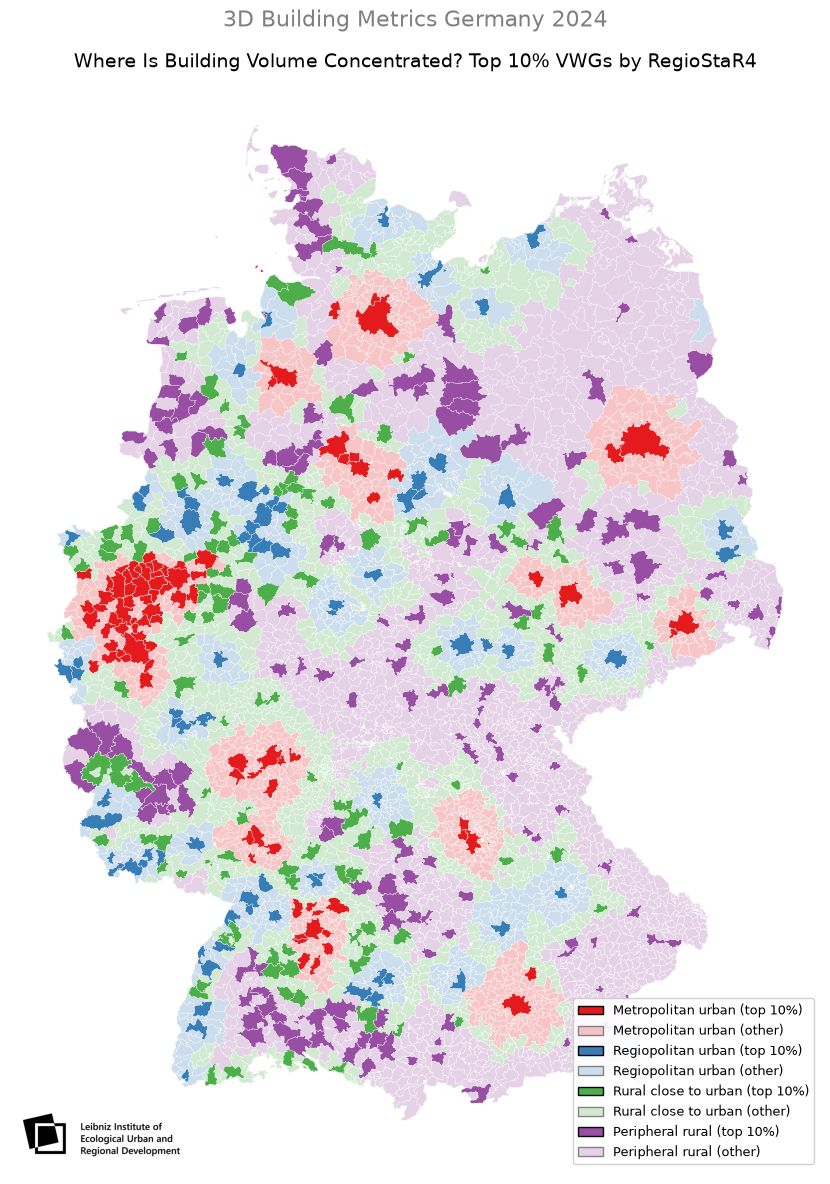

Map saved to: resources\203_map_top10_single.png


In [30]:
# ============================================================
# Single map with all classes
# ============================================================
class_colors = {
    '11': '#e41a1c',  # red
    '12': '#377eb8',  # blue
    '21': '#4daf4a',  # green
    '22': '#984ea3'   # purple
}

# Create color column
def get_color(row):
    base_color = to_rgba(class_colors[row['regiostar4_code']])
    if row['top10']:
        return base_color  # full saturation
    else:
        return (base_color[0], base_color[1], base_color[2], 0.25)  # faint

vwg_geom_join['color'] = vwg_geom_join.apply(get_color, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(14, 12))

# Plot all VWGs
vwg_geom_join.plot(ax=ax, color=vwg_geom_join['color'], edgecolor='white', linewidth=0.2)

# Add legend
legend_elements = []
for code, color in class_colors.items():
    legend_elements.append(
        Patch(facecolor=color, edgecolor='black', label=f"{regiostar4_labels_short[code]} (top 10%)")
    )
    legend_elements.append(
        Patch(facecolor=to_rgba(color, alpha=0.25), edgecolor='grey', 
              label=f"{regiostar4_labels_short[code]} (other)")
    )

ax.legend(handles=legend_elements, loc='lower right', fontsize=9, framealpha=0.9)
fig.suptitle('3D Building Metrics Germany 2024', fontsize=16, y=0.98, color='grey')
ax.set_title('Where Is Building Volume Concentrated? Top 10% VWGs by RegioStaR4', fontsize=14)

ax.axis('off')
plt.tight_layout()

# Logo anchored to the map axes 
logo_ax = ax.inset_axes([0.0, -0.09, 0.24, 0.24])  # bumped bottom up slightly, bigger width/height
logo_ax.imshow(logo_img)
logo_ax.axis('off')

plt.show()

# ============================================================
# Save the map for use in other chapters
# ============================================================
images_dir = ROOT / "resources"
images_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(images_dir / "203_map_top10_single.png", dpi=300, bbox_inches='tight')
print(f"Map saved to: {images_dir.relative_to(ROOT) / '203_map_top10_single.png'}")

### What the Map Shows

The maps reveal distinct spatial patterns of building volume concentration across Germany:

- **Metropolitan regions** — Volume is highly concentrated in a few large centers
- **Rural regions** — Volume is more evenly distributed across many VWGs

These patterns are not just descriptive — they are actionable. They can help **prioritize** where to first implement measures — e.g., circular economy strategies (targeting areas with high material stocks) or energy transition initiatives (targeting areas with high renovation potential). We invite you to explore, adapt, and extend the pipeline to your own research questions — whether in the circular economy, energy transition, or urban resilience.


## 2.5 Try It Yourself: Three Simple Adaptations

The analysis above uses **building volume**, a **top 10%** threshold, and **VWGs** as the spatial unit. Here are three simple ways to adapt the pipeline and explore new patterns.

### Adaptation 1: Change the Variable — From Volume to Roof Area

Building volume is one proxy for material stock. **Roof area** is another — particularly relevant for solar potential and energy transition analyses.

**What to change:**  
Replace `total_volume_m3` with `total_roof_area_m2` in the Lorenz curve calculations (Section 2.2), concentration metrics (Section 2.3), and top 10% identification (Section 2.4).

> **Question to explore:** Does roof area show the same concentration pattern as volume? What does this mean for solar potential or green roof planning?



### Adaptation 2: Change the Threshold — From Top 10% to Top 5% or Top 20%

The top 10% threshold is arbitrary. Changing it reveals different aspects of the distribution.

**What to change:**  
In Section 2.4, modify the threshold from `0.10` to `0.05` (top 5%) or `0.20` (top 20%). Update the map title accordingly.

> **Question to explore:** How do the spatial patterns change? Are the top 5% even more concentrated in metropolitan areas? Does the top 20% reveal secondary centers that were hidden before?


### Adaptation 3: Change the Spatial Unit — From VWGs to Municipalities or Districts

The analysis uses **VWGs** (municipal associations) as the analytical unit. But you can also work with:

- **Municipalities (Gemeinden)** — finer granularity, more detail
- **Districts (Landkreise)** — coarser granularity, regional perspective

**What to change:**  
In Section 2.1, skip the VWG aggregation step and use `agg_merged` directly (municipalities), or group by a district code (first 5 digits of AGS) for the district level.

> **Question to explore:** How do the Lorenz curves and maps change with different spatial units? Does the concentration pattern become stronger or weaker with finer granularity?


> **💡 Your challenge:** Pick one of these adaptations — or combine two — and see what new patterns emerge. Share your findings with the HaCLAthon community!

---

## Summary

In this chapter, we:

- ✅ Prepared the analytical dataset (VWG level with RegioStaR4)
- ✅ Computed Lorenz curves and Gini coefficients
- ✅ Identified top 10% VWGs by building volume
- ✅ Visualized spatial patterns on a map
- ✅ Connected results to sustainability applications

**Key takeaway:** Building volume is highly concentrated in all RegioStaR4 classes — but the degree of concentration varies. In metropolitan urban regions, the top 10% of VWGs hold 60% of building volume. This can help **prioritize** where to first implement sustainability measures.

---

## Citation

If you use this dataset or the pipeline in your work, please cite:

```{code-block} bibtex
@book{muenzinger2026footprints,
  title={From Footprints to Building Stock Insights},
  author={Münzinger, Markus and Behnisch, Martin},
  year={2026},
  publisher={IOER}
}

@dataset{muenzinger2026dataset,
  title={3D Building Metrics Germany 2024},
  author={Münzinger, Markus},
  year={2026},
  publisher={ioerDATA},
  doi={10.71830/9CBBWV}
}
```